# 05_EDA_2 : Normal Operating Regime 분석

## 1. 분석 목적

전체 Normal 시계열을 확인한 결과,
후반부 일부 구간에서 AI0_Vibration, AI1_Vibration의 진폭이 감소하고
AI2_Current의 파형 형태 역시 앞선 구간과 다르게 보이는 현상이 관찰되었다.

특히 약 3600~4400초 부근에서 이러한 변화가 시각적으로 두드러지지만,
본 단계에서는 해당 시간대를 별도의 운전상태로 미리 확정하지 않는다.

본 분석의 목적은 Normal 데이터 내부에 서로 다른 신호 특성을 가지는
Operating Regime 후보가 실제로 존재하는지 확인하고,
앞서 확인한 AI2_Current의 약 1.6~1.7초 반복구조가 이러한 변화에도 유지되는지 검증하는 것이다.

---

## 2. 핵심 검증 질문

### Q1. 변화 구간에서도 AI2의 약 1.6~1.7초 반복주기가 유지되는가?

Normal 전체에서 확인된 AI2_Current의 반복주기가
후반부 신호 변화 구간에서도 동일하게 나타나는지 확인한다.

- Peak-to-Peak interval
- Lagged correlation / ACF
- 필요 시 PSD

를 이용하여 반복시간 구조의 유지 여부를 검증한다.

---

### Q2. 반복주기는 유지되지만 AI0 / AI1 진폭만 변화하는가?

AI2의 반복시간이 유지되는 상태에서
AI0_Vibration과 AI1_Vibration의 신호 크기만 달라지는지 확인한다.

주요 비교 후보:

- Mean
- Standard Deviation
- RMS
- Peak-to-Peak
- Signal Range

반복주기는 유지되면서 진동 진폭만 변한다면,
동일한 시간구조 안에서 서로 다른 Normal 신호 상태가 존재할 가능성을 검토한다.

---

### Q3. AI2_Current 자체의 amplitude 또는 shape도 변화하는가?

AI2_Current의 반복주기뿐 아니라
각 반복구간의 신호 크기와 파형 형태가 달라지는지 확인한다.

주요 비교 후보:

- Mean / Standard Deviation
- RMS
- Peak-to-Peak
- Phase-normalized waveform
- Template RMSE
- Template Correlation

주기가 동일하더라도 파형의 amplitude 또는 shape가 달라질 수 있으므로
시간구조와 파형구조를 분리하여 해석한다.

---

### Q4. 관찰된 변화는 단순 시간대 차이인가, Normal 내부 Operating Regime 후보인가?

후반부에서 관찰된 신호 변화가 단순한 일시적 변동인지,
여러 segment에 걸쳐 지속적으로 나타나는 구조적 변화인지 확인한다.

이를 위해 시간에 따른 segment-level 통계량을 비교한다.

- AI0 / AI1 / AI2 RMS
- Standard Deviation
- Peak-to-Peak
- Segment Median
- AI2 반복주기

특정 시간 이후 여러 특징이 동시에 안정적으로 변화한다면
이를 Normal 내부의 Operating Regime 후보로 정의할 수 있는지 검토한다.

※ 제공된 데이터만으로 부하, 압력, 제품 종류, 금형 상태 등
구체적인 물리적 원인을 확정하지 않는다.

---

### Q5. 전체 Normal에 하나의 Cycle Template을 사용하는 것이 적절한가?

앞선 Cycle EDA에서는 전체 Normal Cycle을 이용하여
하나의 대표 Template을 생성하였다.

하지만 Normal 내부에 서로 다른 Operating Regime이 존재하고
각 Regime의 Cycle shape가 체계적으로 다르다면,
전체 데이터를 하나의 Template으로 표현하는 것이 부적절할 수 있다.

따라서 다음 두 경우를 비교한다.

1. Global Normal Template
2. Regime별 Normal Template

Regime별 Template에서 Template RMSE가 감소하고
Template Correlation이 증가한다면,
Feature Engineering 단계에서 Regime-conditioned Template 사용을 검토한다.

---

## 3. 분석 원칙

- 공식 `preprocessed_data.csv`를 사용한다.
- 기존 `segment_id`를 그대로 사용하고 새로운 segment를 임의로 생성하지 않는다.
- Gap을 넘어 신호를 연결하거나 보간하지 않는다.
- 약 3600~4400초는 현재 시각적으로 관찰된 후보 구간일 뿐 분석 전에 확정하지 않는다.
- Operating Regime의 존재와 물리적 원인을 구분한다.
- 신호 특성 차이가 확인되더라도 이를 즉시 설비 이상 또는 불량으로 해석하지 않는다.
- 본 분석 대상은 모두 Equipment_state = Normal 데이터이다.

---

## 4. 분석 흐름

1. Normal 전체의 시간대별 신호 통계량 확인
2. Regime 변화 후보 구간 탐색
3. 후보 Regime별 AI2 반복주기 비교
4. AI0 / AI1 amplitude 비교
5. AI2 amplitude 및 shape 비교
6. Global Template과 Regime별 Template 비교
7. Normal Operating Regime 후보 여부 최종 정리

In [1]:
# 04_Preprocessing에서 생성한 공식 전처리 데이터를 직접 불러온다.
# Operating Regime 분석은 다른 노트북 실행 여부와 무관하게 단독 실행 가능하게 구성한다.
# 분석 대상은 Normal 데이터이며 기존 TimeStamp, elapsed_sec, segment_id를 그대로 사용한다.
# 약 3600~4400초 구간은 아직 확정하지 않고 전체 Normal 구조부터 다시 확인한다.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for root in [Path.cwd(), *Path.cwd().parents]:
    DATA_PATH=root/"data"/"processed"/"preprocessed_data.csv"
    if DATA_PATH.exists():
        break
else:
    raise FileNotFoundError("data/processed/preprocessed_data.csv를 찾지 못함")

data=pd.read_csv(DATA_PATH,parse_dates=["TimeStamp"])
normal=data[data["source"]=="normal"].copy()

CHANNELS=["AI0_Vibration","AI1_Vibration","AI2_Current"]

print("DATA_PATH       :",DATA_PATH)
print("Normal rows     :",len(normal))
print("Normal segments :",normal["segment_id"].nunique())
print("Elapsed range   :",f"{normal['elapsed_sec'].min():.1f} ~ {normal['elapsed_sec'].max():.1f} sec")

DATA_PATH       : c:\Users\astra\Desktop\K_eng\data\processed\preprocessed_data.csv
Normal rows     : 19999
Normal segments : 599
Elapsed range   : 0.0 ~ 4615.8 sec


In [3]:
# 각 Normal segment를 하나의 관측 단위로 보고 AI0/AI1/AI2의 대표 통계량을 계산한다.
# 시간에 따른 RMS, STD, Peak-to-Peak, Median 변화를 비교하여 Normal 내부 상태 변화 후보를 찾는다.
# 서로 다른 segment를 연결하지 않으며 공식 segment_id와 elapsed_sec를 그대로 사용한다.
# 이후 이 표를 이용해 3600~4400초 부근의 변화가 실제로 구조적인지 확인한다.

segment_rows=[]

for segment_id,group in normal.groupby("segment_id",sort=False):
    row={
        "segment_id":segment_id,
        "n_samples":len(group),
        "start_sec":group["elapsed_sec"].iloc[0],
        "end_sec":group["elapsed_sec"].iloc[-1],
        "mid_sec":(group["elapsed_sec"].iloc[0]+group["elapsed_sec"].iloc[-1])/2
    }

    for channel in CHANNELS:
        x=group[channel].to_numpy(float)
        row[f"{channel}_median"]=np.median(x)
        row[f"{channel}_std"]=np.std(x,ddof=1) if len(x)>1 else np.nan
        row[f"{channel}_rms"]=np.sqrt(np.mean(x**2))
        row[f"{channel}_ptp"]=np.ptp(x)

    segment_rows.append(row)

segment_stats=pd.DataFrame(segment_rows)

print("Segment-level rows :",len(segment_stats))
display(segment_stats.head())

Segment-level rows : 599


,segment_id,n_samples,start_sec,end_sec,mid_sec,AI0_Vibration_median,AI0_Vibration_std,AI0_Vibration_rms,AI0_Vibration_ptp,AI1_Vibration_median,AI1_Vibration_std,AI1_Vibration_rms,AI1_Vibration_ptp,AI2_Current_median,AI2_Current_std,AI2_Current_rms,AI2_Current_ptp
0,N0000,41,0.000,4.000,2.000,-0.010088,0.069511,0.069009,0.320468,-0.029424,0.164929,0.163178,0.542527,25.225046,149.782344,149.170481,439.24885
1,N0001,37,7.205,10.805,9.005,0.018289,0.074072,0.073404,0.244890,-0.025517,0.134060,0.132412,0.425441,-9.568335,141.555912,139.745235,433.55648
2,N0002,24,15.248,17.548,16.398,-0.015134,0.040329,0.040946,0.139259,-0.005973,0.050395,0.049729,0.178882,-14.467897,81.567430,80.082896,220.65249
3,N0003,10,23.305,24.205,23.755,0.027390,0.050578,0.055487,0.159718,0.012238,0.131400,0.126459,0.361909,29.732708,162.419616,154.819184,415.93938
4,N0004,50,32.733,37.633,35.183,-0.005928,0.039726,0.039326,0.162124,-0.001533,0.048760,0.048270,0.199749,0.345230,82.372310,81.545626,221.60950


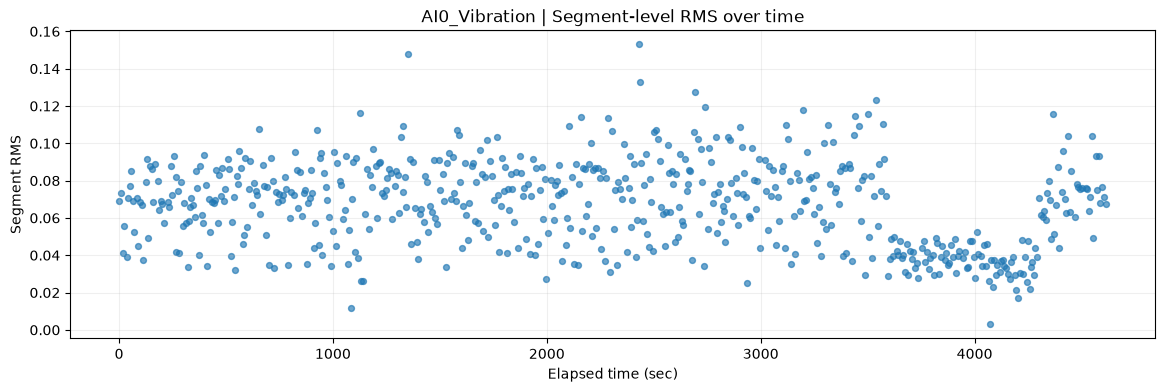

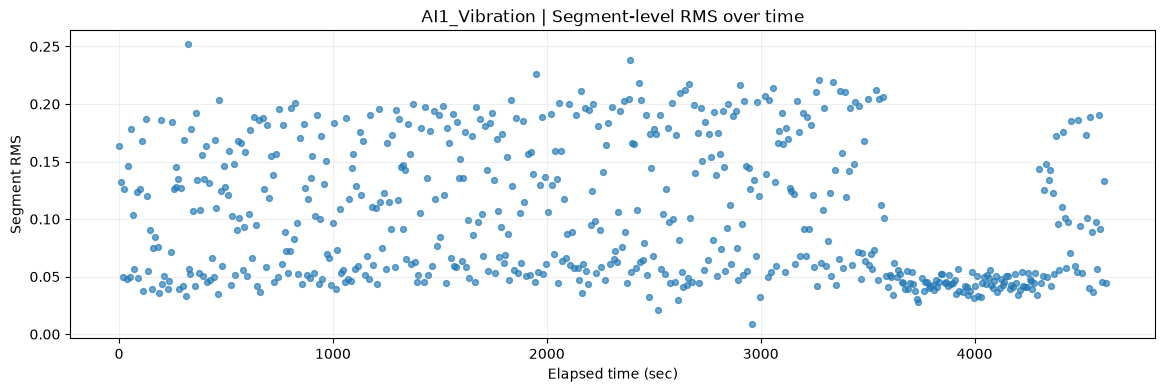

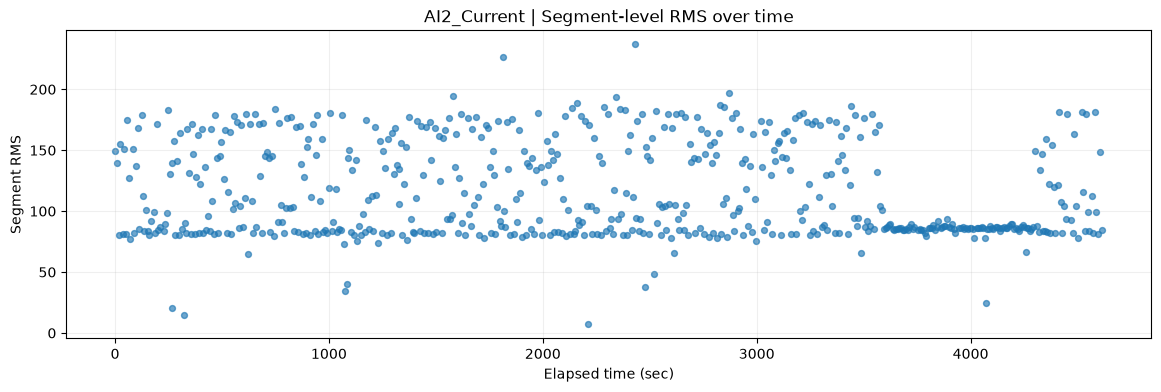

In [4]:
# 각 Normal segment의 RMS가 시간에 따라 어떻게 변하는지 채널별로 확인한다.
# AI0/AI1/AI2는 값의 크기가 크게 다르므로 서로 다른 그래프로 분리하여 표시한다.
# 아직 3600~4400초를 별도 Regime으로 확정하지 않고 전체 시간구조를 먼저 관찰한다.
# 여러 연속 segment에서 RMS 수준이 함께 변하는 구간이 존재하는지가 핵심 확인 대상이다.

for channel in CHANNELS:
    y=segment_stats[f"{channel}_rms"]

    fig,ax=plt.subplots(figsize=(14,4))

    ax.scatter(
        segment_stats["mid_sec"],
        y,
        s=18,
        alpha=.65
    )

    ax.set_title(f"{channel} | Segment-level RMS over time")
    ax.set_xlabel("Elapsed time (sec)")
    ax.set_ylabel("Segment RMS")
    ax.grid(alpha=.2)

    plt.show()

,time_bin,AI0_Vibration_rms,AI1_Vibration_rms,AI2_Current_rms
0,0,0.069013,0.087498,98.742204
1,300,0.069314,0.107627,116.119948
2,600,0.073650,0.110888,119.310174
3,900,0.069493,0.096699,87.581434
4,1200,0.074826,0.116942,129.862271
5,1500,0.074724,0.114166,123.465370
6,1800,0.073163,0.114972,123.786278
7,2100,0.078804,0.089947,99.242471
8,2400,0.077960,0.100752,105.117660
9,2700,0.073187,0.134099,137.118354


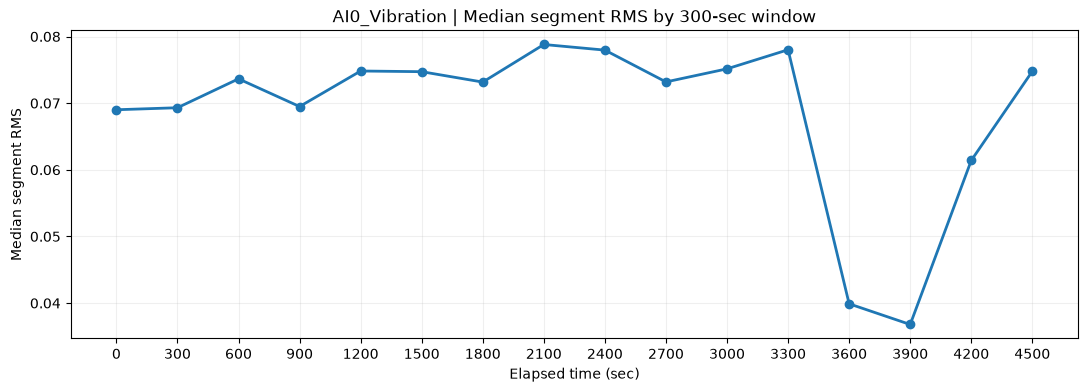

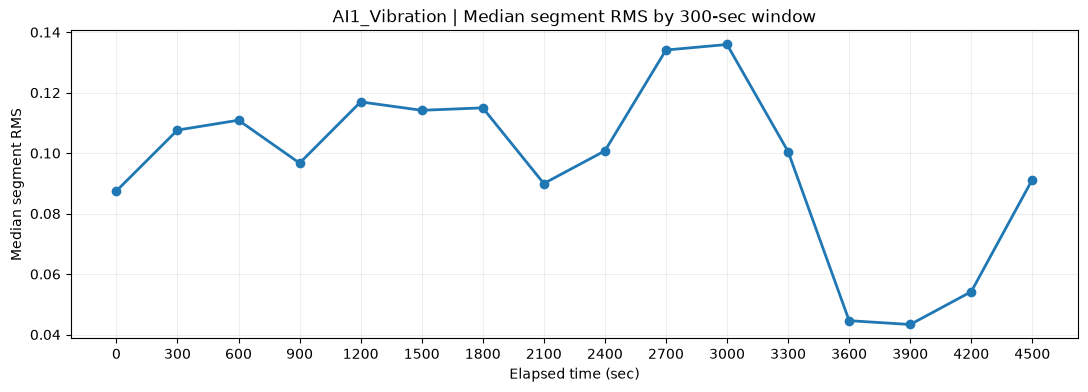

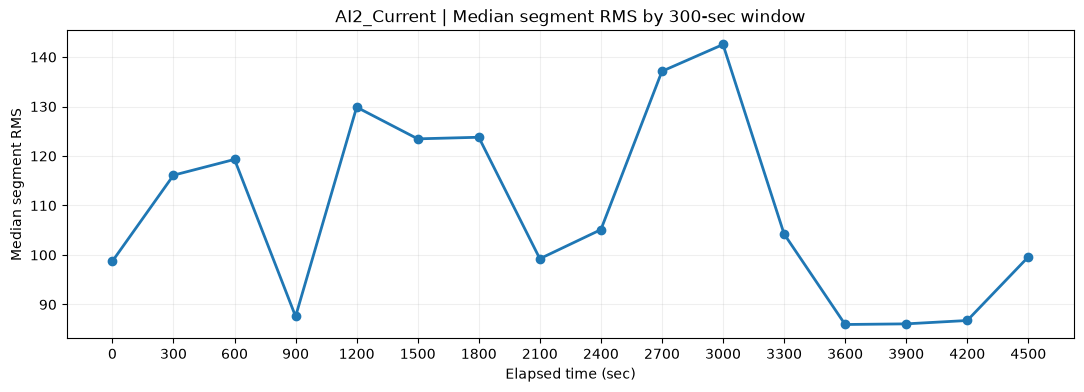

In [5]:
# Normal 전체 시간을 300초 단위로 나누어 segment-level RMS의 중앙값 변화를 확인한다.
# 특정 시간구간을 미리 Regime으로 지정하지 않고 시간대별 대표값으로 상태 변화를 객관화한다.
# AI0/AI1/AI2가 같은 시간대에서 동시에 변화하는지 비교한다.
# 지속적인 수준 변화가 확인되면 이후 Operating Regime 후보 구간 정의에 사용한다.

TIME_BIN_SEC=300

segment_stats["time_bin"]=(
    np.floor(segment_stats["mid_sec"]/TIME_BIN_SEC)*TIME_BIN_SEC
).astype(int)

rms_bin=(
    segment_stats
    .groupby("time_bin")[
        [
            "AI0_Vibration_rms",
            "AI1_Vibration_rms",
            "AI2_Current_rms"
        ]
    ]
    .median()
    .reset_index()
)

display(rms_bin)

for channel in CHANNELS:
    fig,ax=plt.subplots(figsize=(13,4))

    ax.plot(
        rms_bin["time_bin"],
        rms_bin[f"{channel}_rms"],
        marker="o",
        linewidth=2
    )

    ax.set_title(f"{channel} | Median segment RMS by 300-sec window")
    ax.set_xlabel("Elapsed time (sec)")
    ax.set_ylabel("Median segment RMS")
    ax.set_xticks(rms_bin["time_bin"])
    ax.grid(alpha=.2)

    plt.show()

In [6]:
# 약 3600~4300초에서 관찰된 Low-RMS 상태를 임시 Regime 후보로 정의한다.
# 후보 구간 내부와 나머지 Normal segment에서 AI2_Current 반복주기를 동일한 방법으로 추정한다.
# 각 segment 내부에서 1.2~2.2초 lag의 correlation을 비교하여 최적 반복주기를 선택한다.
# Low-RMS 상태에서도 약 1.6~1.7초가 유지되는지가 첫 번째 핵심 검증이다.

LOW_START=3600
LOW_END=4300

SAMPLE_INTERVAL=.1
MIN_LAG=12
MAX_LAG=22

def estimate_ai2_period(group):
    y=group["AI2_Current"].to_numpy(float)

    if len(y)<=MAX_LAG:
        return np.nan,np.nan

    y=y-y.mean()
    if np.std(y)==0:
        return np.nan,np.nan

    correlations=[]

    for lag in range(MIN_LAG,MAX_LAG+1):
        x1=y[:-lag]
        x2=y[lag:]

        if len(x1)<5 or np.std(x1)==0 or np.std(x2)==0:
            correlations.append(np.nan)
        else:
            correlations.append(np.corrcoef(x1,x2)[0,1])

    correlations=np.asarray(correlations,float)

    if np.all(np.isnan(correlations)):
        return np.nan,np.nan

    best_idx=np.nanargmax(correlations)
    best_lag=MIN_LAG+best_idx

    return best_lag*SAMPLE_INTERVAL,correlations[best_idx]

period_rows=[]

for segment_id,group in normal.groupby("segment_id",sort=False):
    mid_sec=(group["elapsed_sec"].iloc[0]+group["elapsed_sec"].iloc[-1])/2
    period_sec,corr=estimate_ai2_period(group)

    period_rows.append({
        "segment_id":segment_id,
        "mid_sec":mid_sec,
        "regime":"Low-RMS candidate" if LOW_START<=mid_sec<=LOW_END else "Other Normal",
        "period_sec":period_sec,
        "acf_corr":corr
    })

regime_period=pd.DataFrame(period_rows).dropna(subset=["period_sec"])

regime_period["period_rounded"]=regime_period["period_sec"].round(1)
regime_period["is_1_6_to_1_7"]=regime_period["period_rounded"].between(1.6,1.7)

period_compare=(
    regime_period
    .groupby("regime")
    .agg(
        segments=("period_sec","size"),
        median_period_sec=("period_sec","median"),
        median_corr=("acf_corr","median"),
        ratio_1_6_to_1_7=("is_1_6_to_1_7","mean")
    )
)

display(period_compare)

,segments,median_period_sec,median_corr,ratio_1_6_to_1_7
regime,,,,
Low-RMS candidate,65,1.7,0.991738,1.0
Other Normal,359,1.7,0.991950,1.0


In [7]:
# Low-RMS 후보와 나머지 Normal의 신호 amplitude 특성을 직접 비교한다.
# AI0/AI1/AI2 각각에 대해 RMS, STD, Peak-to-Peak의 중앙값을 계산한다.
# 반복주기가 동일한 상태에서 실제 신호 크기가 얼마나 달라지는지 확인한다.
# 이를 통해 시간구조와 amplitude 변화가 서로 분리되는지 검증한다.

segment_stats["regime"]=np.where(
    segment_stats["mid_sec"].between(LOW_START,LOW_END),
    "Low-RMS candidate",
    "Other Normal"
)

metrics=[]

for channel in CHANNELS:
    for metric in ["rms","std","ptp"]:
        col=f"{channel}_{metric}"

        summary=(
            segment_stats
            .groupby("regime")[col]
            .agg(["count","median","mean"])
        )

        low=summary.loc["Low-RMS candidate"]
        other=summary.loc["Other Normal"]

        metrics.append({
            "channel":channel,
            "metric":metric,
            "low_median":low["median"],
            "other_median":other["median"],
            "low_to_other_ratio":low["median"]/other["median"]
        })

amplitude_compare=pd.DataFrame(metrics)

display(amplitude_compare)

,channel,metric,low_median,other_median,low_to_other_ratio
0,AI0_Vibration,rms,0.037997,0.073352,0.518003
1,AI0_Vibration,std,0.038496,0.073906,0.520882
2,AI0_Vibration,ptp,0.140446,0.286863,0.489591
3,AI1_Vibration,rms,0.044137,0.107373,0.411064
4,AI1_Vibration,std,0.044633,0.105702,0.422253
5,AI1_Vibration,ptp,0.176492,0.333434,0.529318
6,AI2_Current,rms,86.010107,110.944281,0.775255
7,AI2_Current,std,86.674613,107.110553,0.809207
8,AI2_Current,ptp,231.909180,314.777180,0.736741


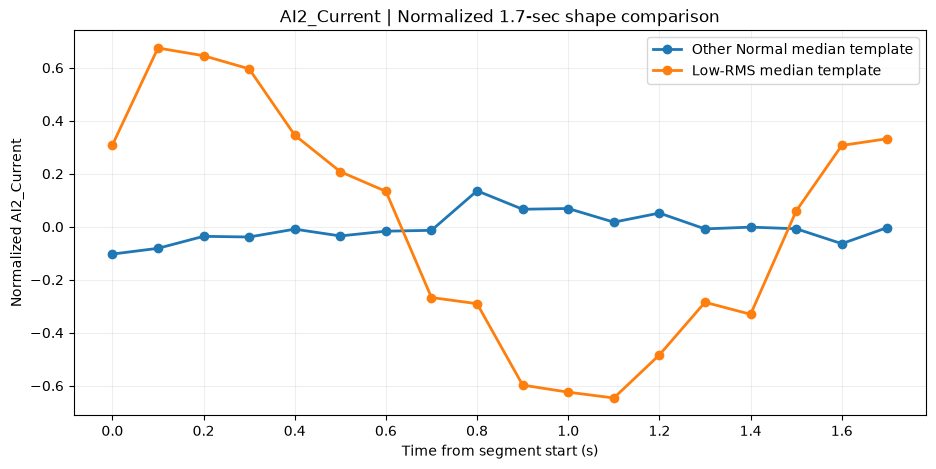

Low-RMS segments : 68
Other segments   : 395
Template correlation : -0.721881
Template RMSE        : 0.480101


In [8]:
# Low-RMS 후보와 Other Normal의 AI2 반복파형 shape를 amplitude와 분리하여 비교한다.
# 각 segment 시작점부터 17 samples 뒤까지 총 18개 값을 하나의 약 1.7초 파형으로 사용한다.
# 각 파형을 평균 0, 표준편차 1로 정규화하여 절대 진폭 차이를 제거하고 shape만 비교한다.
# 두 Regime의 Median Template correlation이 높다면 amplitude는 달라도 기본 파형 형태는 유지된다고 본다.

CYCLE_SAMPLES=18

shape_rows=[]

for segment_id,group in normal.groupby("segment_id",sort=False):
    if len(group)<CYCLE_SAMPLES:
        continue

    mid_sec=(group["elapsed_sec"].iloc[0]+group["elapsed_sec"].iloc[-1])/2
    regime="Low-RMS candidate" if LOW_START<=mid_sec<=LOW_END else "Other Normal"

    y=group["AI2_Current"].to_numpy(float)[:CYCLE_SAMPLES]
    y_std=np.std(y)

    if y_std<=0:
        continue

    y_norm=(y-y.mean())/y_std

    shape_rows.append({
        "segment_id":segment_id,
        "regime":regime,
        "waveform":y_norm
    })

low_matrix=np.vstack([
    r["waveform"] for r in shape_rows
    if r["regime"]=="Low-RMS candidate"
])

other_matrix=np.vstack([
    r["waveform"] for r in shape_rows
    if r["regime"]=="Other Normal"
])

low_template=np.median(low_matrix,axis=0)
other_template=np.median(other_matrix,axis=0)

template_corr=np.corrcoef(low_template,other_template)[0,1]
template_rmse=np.sqrt(np.mean((low_template-other_template)**2))

time_axis=np.arange(CYCLE_SAMPLES)*SAMPLE_INTERVAL

fig,ax=plt.subplots(figsize=(11,5))

ax.plot(
    time_axis,
    other_template,
    marker="o",
    linewidth=2,
    label="Other Normal median template"
)

ax.plot(
    time_axis,
    low_template,
    marker="o",
    linewidth=2,
    label="Low-RMS median template"
)

ax.set_title("AI2_Current | Normalized 1.7-sec shape comparison")
ax.set_xlabel("Time from segment start (s)")
ax.set_ylabel("Normalized AI2_Current")
ax.set_xticks(time_axis[::2])
ax.grid(alpha=.2)
ax.legend()

plt.show()

print(f"Low-RMS segments : {len(low_matrix)}")
print(f"Other segments   : {len(other_matrix)}")
print(f"Template correlation : {template_corr:.6f}")
print(f"Template RMSE        : {template_rmse:.6f}")

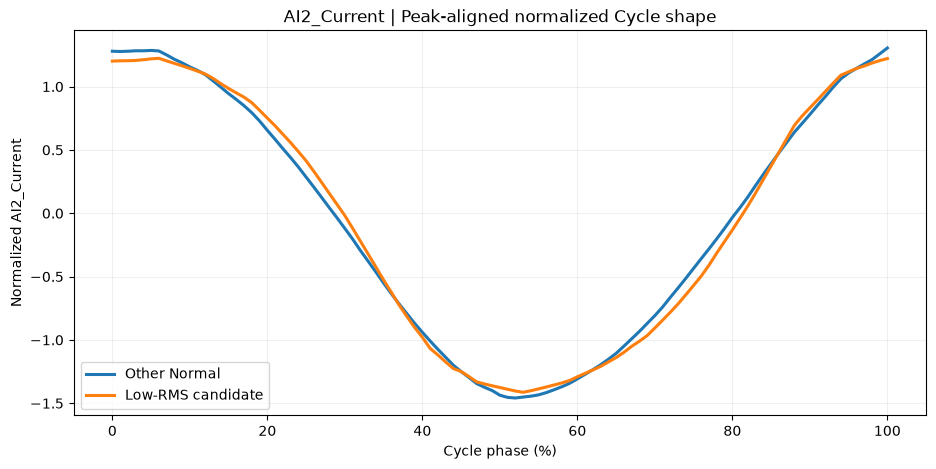

Low-RMS cycles   : 67
Other cycles     : 408
Template correlation : 0.997489
Template RMSE        : 0.068816


In [9]:
# AI2 Peak-to-Peak Cycle을 이용하여 Low-RMS와 Other Normal의 파형 shape를 비교한다.
# Segment 시작점 대신 Peak를 공통 위상 0%로 사용하여 시작 위상 차이로 인한 파형 상쇄를 제거한다.
# 각 Cycle은 0~100% phase로 보간하고 z-score 정규화하여 amplitude 영향을 제거한다.
# 두 Regime의 Median Template correlation으로 반복주기는 같지만 shape도 동일한지 검증한다.

from scipy.signal import find_peaks

MIN_PEAK_DISTANCE=12
PHASE_POINTS=101
phase=np.linspace(0,1,PHASE_POINTS)

cycle_shapes=[]

for segment_id,group in normal.groupby("segment_id",sort=False):
    if len(group)<30:
        continue

    y=group["AI2_Current"].to_numpy(float)
    smooth=pd.Series(y).rolling(3,center=True,min_periods=1).median().to_numpy()

    prominence=max(
        float(np.std(smooth,ddof=1))*.5,
        np.finfo(float).eps
    )

    peaks,_=find_peaks(
        smooth,
        distance=MIN_PEAK_DISTANCE,
        prominence=prominence
    )

    for start,stop in zip(peaks[:-1],peaks[1:]):
        if stop-start<MIN_PEAK_DISTANCE:
            continue

        cycle=group.iloc[start:stop+1]
        x=cycle["AI2_Current"].to_numpy(float)

        if np.std(x)<=0:
            continue

        cycle_phase=np.linspace(0,1,len(x))
        x_norm=(x-x.mean())/x.std()
        x_phase=np.interp(phase,cycle_phase,x_norm)

        cycle_mid=(
            cycle["elapsed_sec"].iloc[0]
            +cycle["elapsed_sec"].iloc[-1]
        )/2

        cycle_shapes.append({
            "segment_id":segment_id,
            "regime":"Low-RMS candidate" if LOW_START<=cycle_mid<=LOW_END else "Other Normal",
            "waveform":x_phase
        })

low_matrix=np.vstack([
    x["waveform"] for x in cycle_shapes
    if x["regime"]=="Low-RMS candidate"
])

other_matrix=np.vstack([
    x["waveform"] for x in cycle_shapes
    if x["regime"]=="Other Normal"
])

low_template=np.median(low_matrix,axis=0)
other_template=np.median(other_matrix,axis=0)

template_corr=np.corrcoef(
    low_template,
    other_template
)[0,1]

template_rmse=np.sqrt(
    np.mean((low_template-other_template)**2)
)

phase_percent=phase*100

fig,ax=plt.subplots(figsize=(11,5))

ax.plot(
    phase_percent,
    other_template,
    linewidth=2.2,
    label="Other Normal"
)

ax.plot(
    phase_percent,
    low_template,
    linewidth=2.2,
    label="Low-RMS candidate"
)

ax.set_title("AI2_Current | Peak-aligned normalized Cycle shape")
ax.set_xlabel("Cycle phase (%)")
ax.set_ylabel("Normalized AI2_Current")
ax.grid(alpha=.2)
ax.legend()

plt.show()

print(f"Low-RMS cycles   : {len(low_matrix)}")
print(f"Other cycles     : {len(other_matrix)}")
print(f"Template correlation : {template_corr:.6f}")
print(f"Template RMSE        : {template_rmse:.6f}")

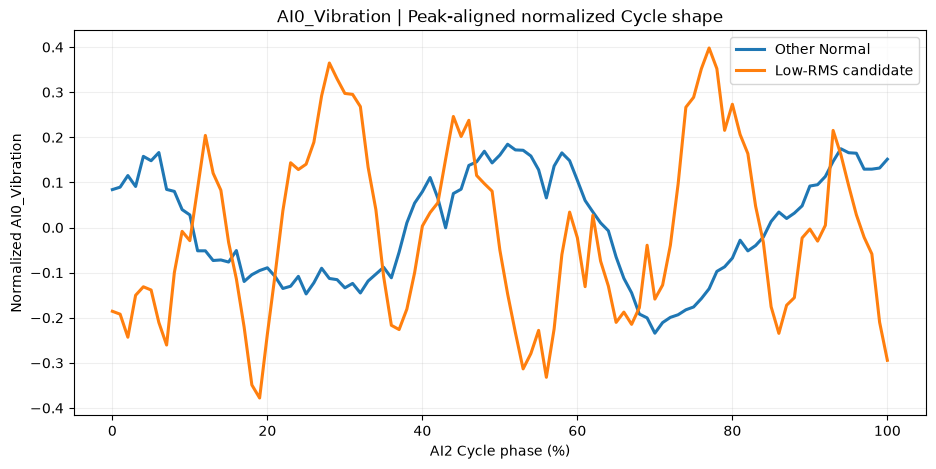

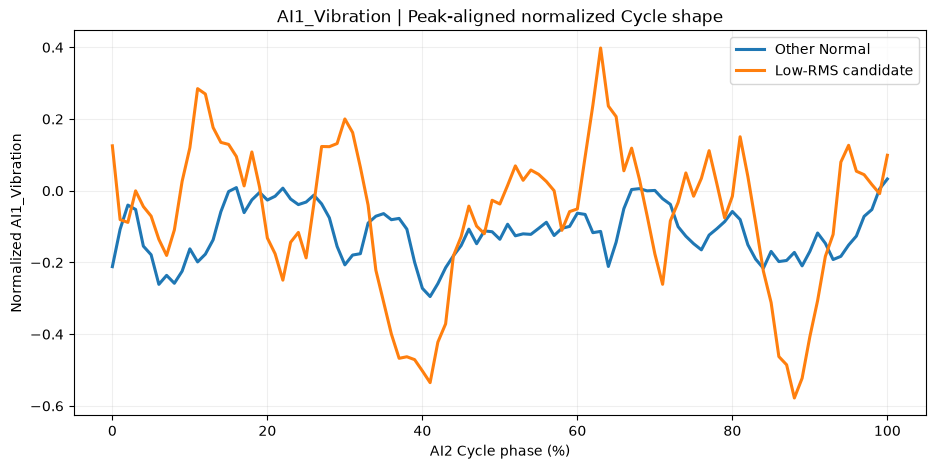

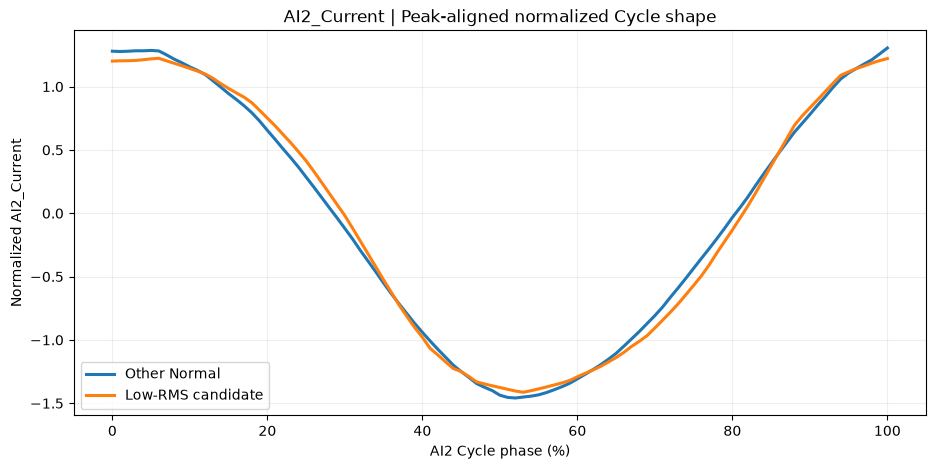

,channel,low_cycles,other_cycles,template_correlation,template_rmse
0,AI0_Vibration,67,408,-0.288216,0.252431
1,AI1_Vibration,67,408,0.234592,0.206901
2,AI2_Current,67,408,0.997489,0.068816


In [10]:
# AI2 Peak-to-Peak 경계를 공통 기준으로 사용해 AI0/AI1/AI2의 Cycle shape를 비교한다.
# 각 Cycle의 amplitude 차이를 제거하기 위해 채널별로 z-score 정규화 후 0~100% phase에 정렬한다.
# Low-RMS와 Other Normal의 Median Template correlation과 RMSE를 채널별로 계산한다.
# 이를 통해 전류뿐 아니라 진동 파형의 기본 shape도 Regime 사이에서 유지되는지 확인한다.

from scipy.signal import find_peaks

SHAPE_CHANNELS=["AI0_Vibration","AI1_Vibration","AI2_Current"]
MIN_PEAK_DISTANCE=12
PHASE_POINTS=101
phase=np.linspace(0,1,PHASE_POINTS)

shape_records=[]

for segment_id,group in normal.groupby("segment_id",sort=False):
    if len(group)<30:
        continue

    anchor=group["AI2_Current"].to_numpy(float)
    smooth=pd.Series(anchor).rolling(3,center=True,min_periods=1).median().to_numpy()
    prominence=max(float(np.std(smooth,ddof=1))*.5,np.finfo(float).eps)

    peaks,_=find_peaks(
        smooth,
        distance=MIN_PEAK_DISTANCE,
        prominence=prominence
    )

    for start,stop in zip(peaks[:-1],peaks[1:]):
        if stop-start<MIN_PEAK_DISTANCE:
            continue

        cycle=group.iloc[start:stop+1]
        cycle_phase=np.linspace(0,1,len(cycle))
        cycle_mid=(cycle["elapsed_sec"].iloc[0]+cycle["elapsed_sec"].iloc[-1])/2
        regime="Low-RMS candidate" if LOW_START<=cycle_mid<=LOW_END else "Other Normal"

        for channel in SHAPE_CHANNELS:
            x=cycle[channel].to_numpy(float)

            if np.std(x)<=0:
                continue

            x_norm=(x-x.mean())/x.std()
            x_phase=np.interp(phase,cycle_phase,x_norm)

            shape_records.append({
                "segment_id":segment_id,
                "regime":regime,
                "channel":channel,
                "waveform":x_phase
            })

shape_summary=[]

for channel in SHAPE_CHANNELS:
    low=np.vstack([
        r["waveform"] for r in shape_records
        if r["channel"]==channel and r["regime"]=="Low-RMS candidate"
    ])

    other=np.vstack([
        r["waveform"] for r in shape_records
        if r["channel"]==channel and r["regime"]=="Other Normal"
    ])

    low_template=np.median(low,axis=0)
    other_template=np.median(other,axis=0)

    corr=np.corrcoef(low_template,other_template)[0,1]
    rmse=np.sqrt(np.mean((low_template-other_template)**2))

    shape_summary.append({
        "channel":channel,
        "low_cycles":len(low),
        "other_cycles":len(other),
        "template_correlation":corr,
        "template_rmse":rmse
    })

    fig,ax=plt.subplots(figsize=(11,5))

    ax.plot(
        phase*100,
        other_template,
        linewidth=2.2,
        label="Other Normal"
    )

    ax.plot(
        phase*100,
        low_template,
        linewidth=2.2,
        label="Low-RMS candidate"
    )

    ax.set_title(f"{channel} | Peak-aligned normalized Cycle shape")
    ax.set_xlabel("AI2 Cycle phase (%)")
    ax.set_ylabel(f"Normalized {channel}")
    ax.grid(alpha=.2)
    ax.legend()

    plt.show()

shape_compare=pd.DataFrame(shape_summary)

display(shape_compare)

In [11]:
# 각 Regime 내부에서 Cycle들이 자기 Regime Median Template과 얼마나 유사한지 확인한다.
# AI0/AI1의 낮은 cross-Regime correlation이 실제 shape 변화인지 낮은 phase-lock 때문인지 구분한다.
# 각 Cycle과 해당 Regime Template 사이의 correlation을 계산하고 Median으로 요약한다.
# 내부 correlation까지 낮다면 해당 채널은 AI2 phase에 안정적으로 고정된 반복파형이 아니라고 해석한다.

consistency_rows=[]

for channel in SHAPE_CHANNELS:
    for regime in ["Other Normal","Low-RMS candidate"]:

        matrix=np.vstack([
            r["waveform"] for r in shape_records
            if r["channel"]==channel and r["regime"]==regime
        ])

        template=np.median(matrix,axis=0)
        correlations=[]
        rmses=[]

        for waveform in matrix:
            corr=np.corrcoef(waveform,template)[0,1]
            rmse=np.sqrt(np.mean((waveform-template)**2))

            correlations.append(corr)
            rmses.append(rmse)

        consistency_rows.append({
            "channel":channel,
            "regime":regime,
            "n_cycles":len(matrix),
            "median_internal_corr":np.nanmedian(correlations),
            "q25_internal_corr":np.nanquantile(correlations,.25),
            "q75_internal_corr":np.nanquantile(correlations,.75),
            "median_internal_rmse":np.nanmedian(rmses)
        })

shape_consistency=pd.DataFrame(consistency_rows)

display(shape_consistency)

,channel,regime,n_cycles,median_internal_corr,q25_internal_corr,q75_internal_corr,median_internal_rmse
0,AI0_Vibration,Other Normal,408,0.169890,-0.097015,0.357864,0.805101
1,AI0_Vibration,Low-RMS candidate,67,0.235862,-0.148148,0.462387,0.731952
2,AI1_Vibration,Other Normal,408,0.074579,-0.150564,0.204942,0.882930
3,AI1_Vibration,Low-RMS candidate,67,0.192327,-0.066656,0.467683,0.751899
4,AI2_Current,Other Normal,408,0.997079,0.993390,0.998473,0.074769
5,AI2_Current,Low-RMS candidate,67,0.998424,0.995594,0.999135,0.054562
